In [688]:
import pandas as pd
from utils import show_missing_values, num_corr_heatmap, cat_corr_heatmap, cramers_v_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import missingno as msno
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
import graphviz

In [689]:
sns.set(style="whitegrid")
pd.set_option('display.max_columns', 100)
healthy_orange = '#EC6602'
healthy_orange_50 = '#F9B591'
healthy_orange_25 = '#FDDDCB'
siemens_petrol = '#009999'
siemens_petrol_50 = '#87D2D2'
sns.set_palette([healthy_orange, siemens_petrol, healthy_orange_50, healthy_orange_25, siemens_petrol_50])
RANDOM_SEED = 42

In [690]:
def plot_confusion_matrix(cm, classes):
    sns.heatmap(cm, annot=True, xticklabels=classes, yticklabels=classes, cmap='Oranges', fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

def dt_graph(model):
    dot_data = export_graphviz(
        model.named_steps['clf'],
        out_file=None,
        feature_names=model.named_steps['prep'].get_feature_names_out(),
        class_names=model.named_steps['clf'].classes_,
        filled=True,
        rounded=True,
        special_characters=True
    )
    
    graph = graphviz.Source(dot_data)
    return graph

In [691]:
df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [692]:
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,species,nan,nan,3,0,0.0%,object
2,island,nan,nan,3,0,0.0%,object
3,bill_length_mm,32.1,59.6,164,2,0.581%,float64
4,bill_depth_mm,13.1,21.5,80,2,0.581%,float64
5,flipper_length_mm,172.0,231.0,55,2,0.581%,float64
6,body_mass_g,2700.0,6300.0,94,2,0.581%,float64
7,sex,nan,nan,2,11,3.198%,object


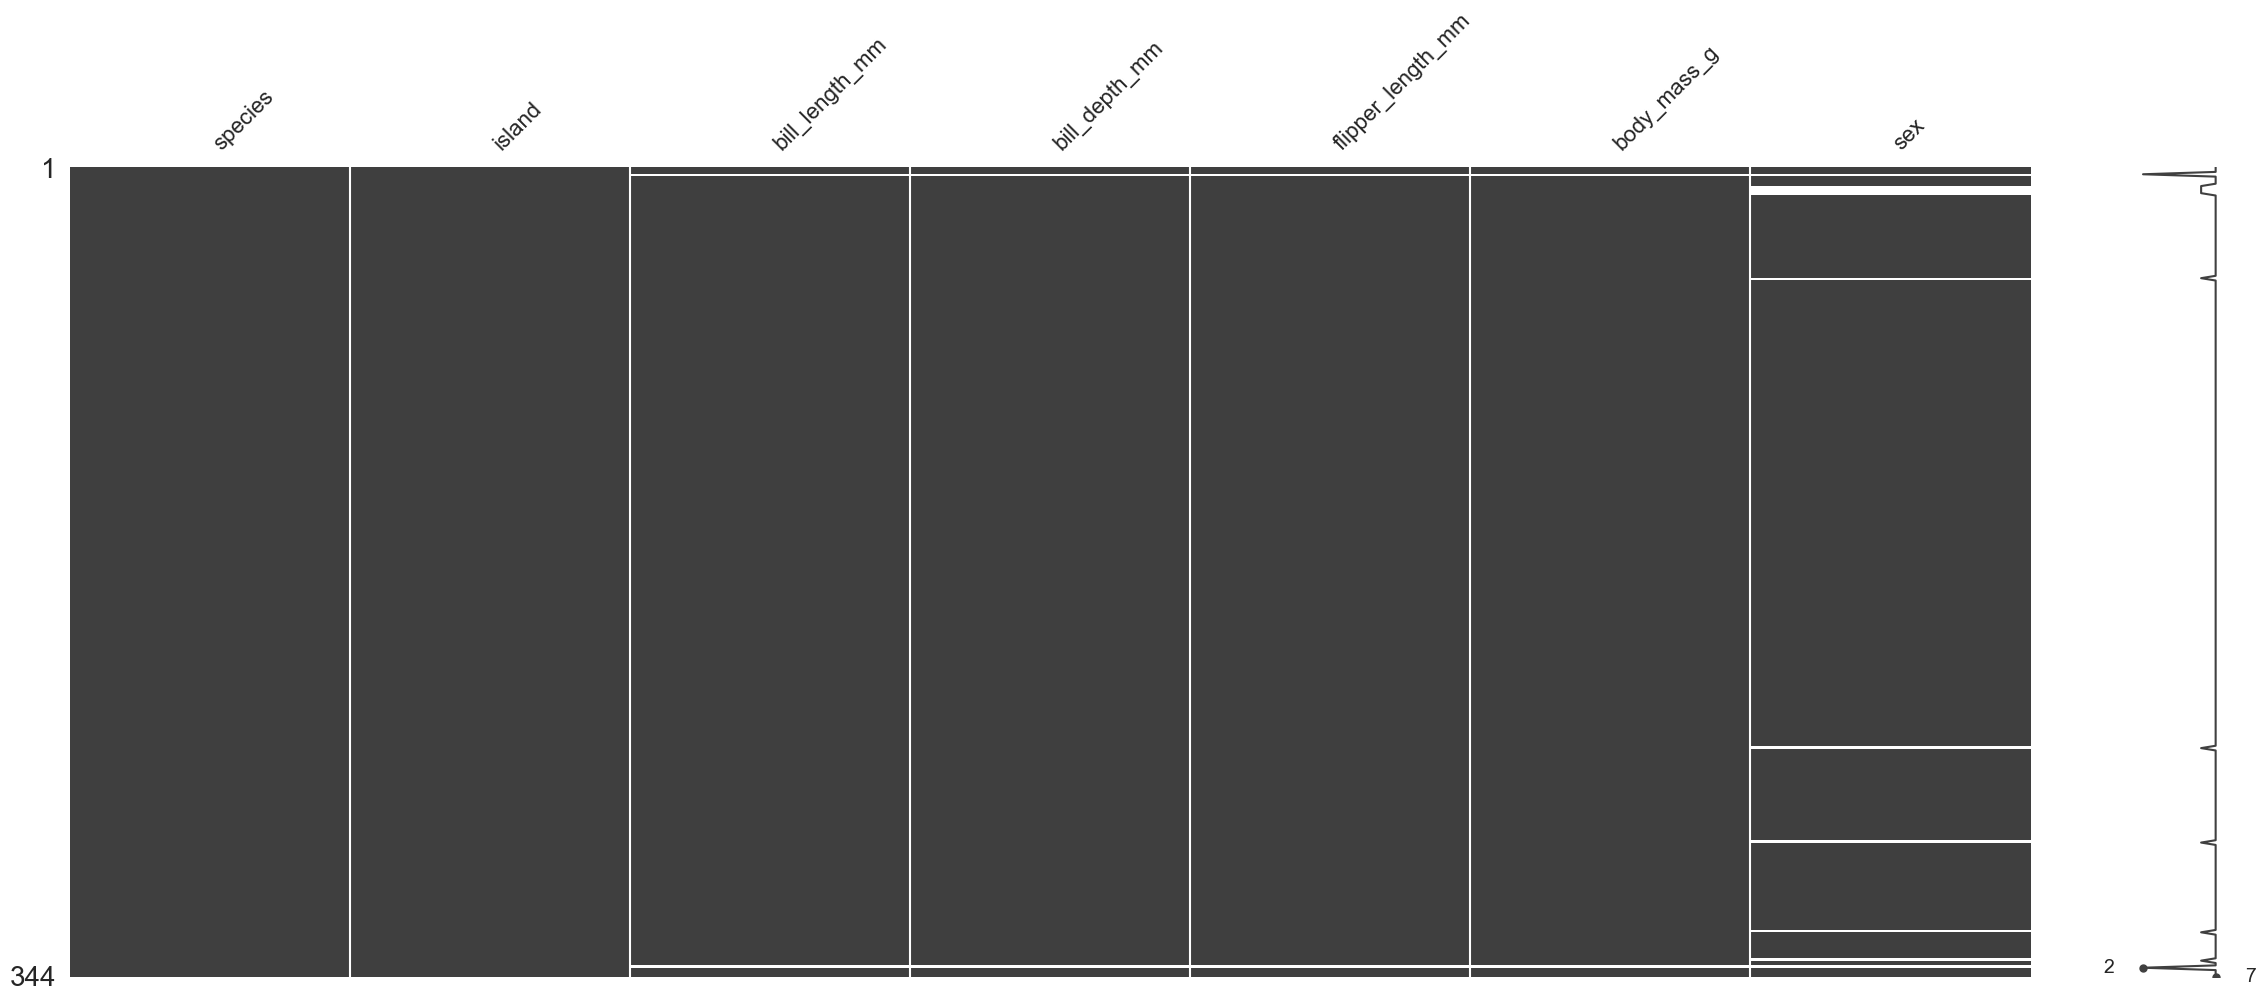

In [693]:
msno.matrix(df);

In [694]:
df = df.dropna(subset=['bill_length_mm'])
show_missing_values(df)

,Column Name,Min,Max,n Unique,NaN count,NaN percentage,dtype
S. No.,,,,,,,
1,species,nan,nan,3,0,0.0%,object
2,island,nan,nan,3,0,0.0%,object
3,bill_length_mm,32.1,59.6,164,0,0.0%,float64
4,bill_depth_mm,13.1,21.5,80,0,0.0%,float64
5,flipper_length_mm,172.0,231.0,55,0,0.0%,float64
6,body_mass_g,2700.0,6300.0,94,0,0.0%,float64
7,sex,nan,nan,2,9,2.632%,object


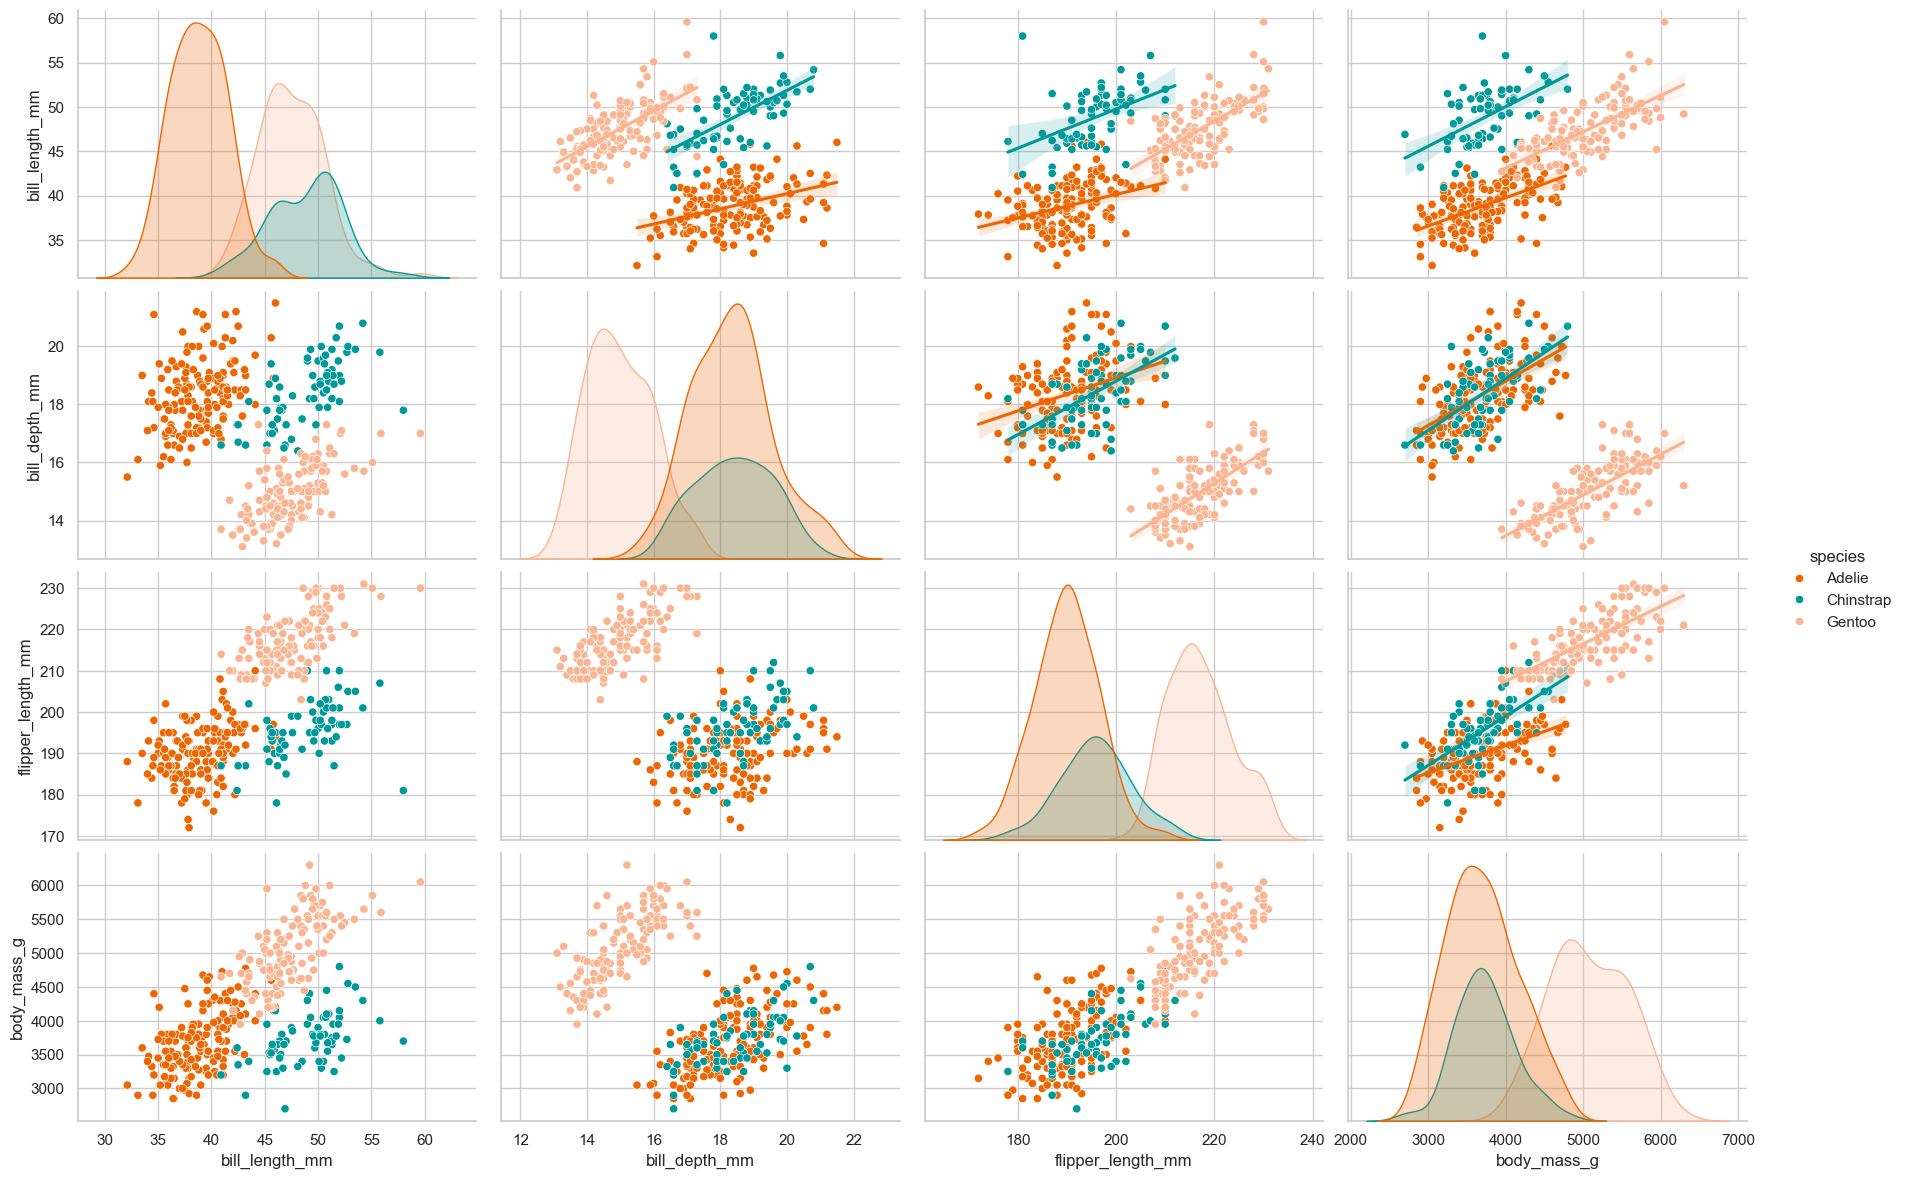

In [695]:
g = sns.pairplot(df, hue='species', diag_kind='kde', height=3, aspect=1.5);
g.map_upper(sns.regplot, scatter=False);

In [696]:
plt.style.use("fivethirtyeight")

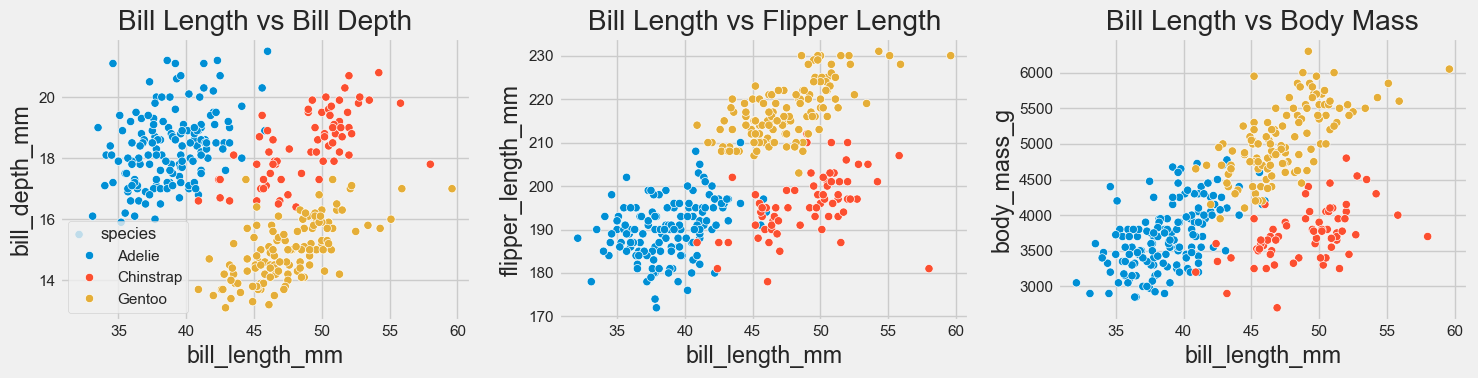

In [697]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=axes[0]);
axes[0].set_title('Bill Length vs Bill Depth');
sns.scatterplot(data=df, x='bill_length_mm', y='flipper_length_mm', hue='species', ax=axes[1]);
axes[1].set_title('Bill Length vs Flipper Length');
axes[1].legend_.remove();
sns.scatterplot(data=df, x='bill_length_mm', y='body_mass_g', hue='species', ax=axes[2]);
axes[2].set_title('Bill Length vs Body Mass');
axes[2].legend_.remove();
plt.tight_layout();
plt.show()

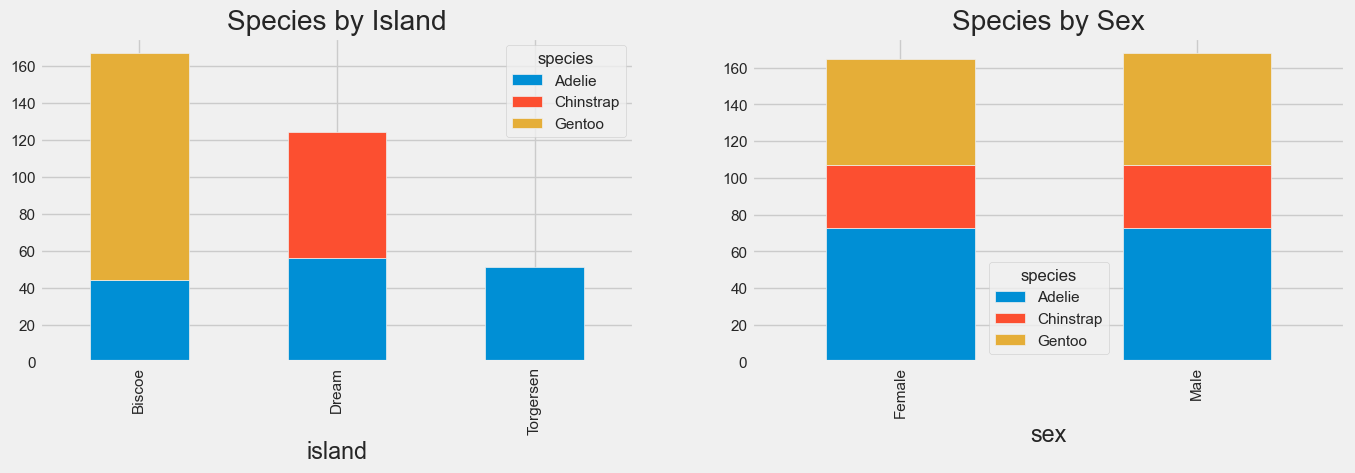

In [698]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
pd.crosstab(df.island, df.species).plot.bar(stacked=True, ax=axes[0]);
axes[0].set_title('Species by Island');
pd.crosstab(df.sex, df.species).plot.bar(stacked=True, ax=axes[1]);
axes[1].set_title('Species by Sex');

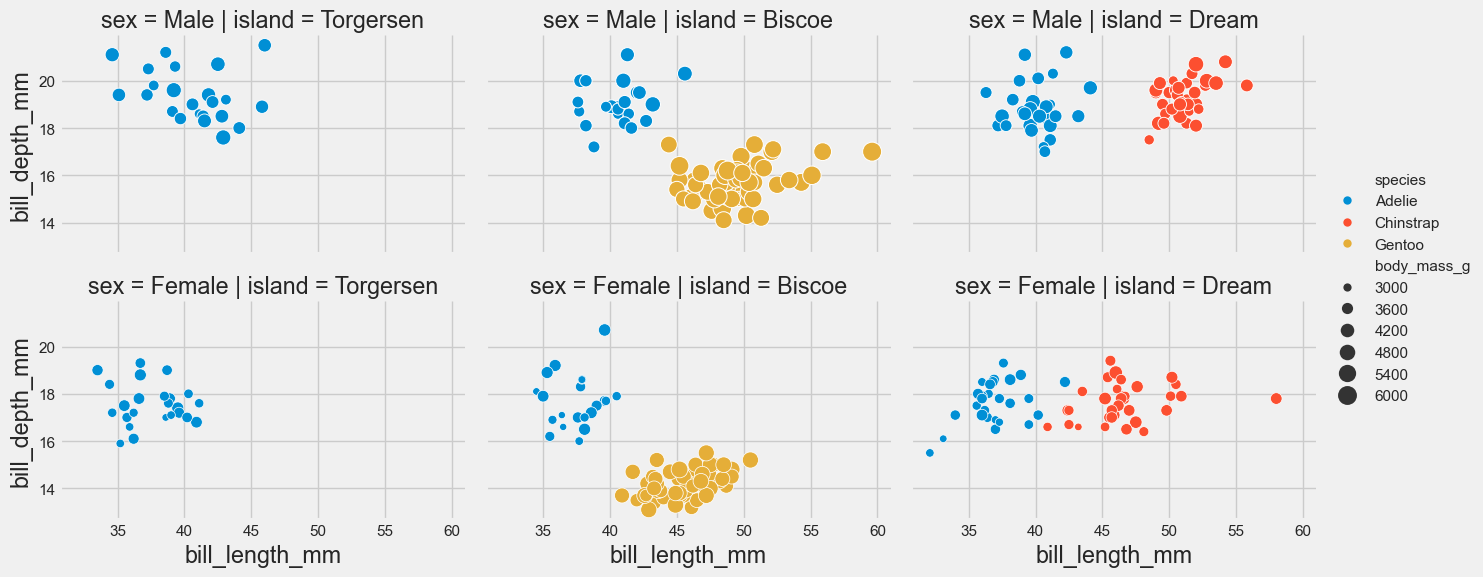

In [699]:
sns.relplot(x='bill_length_mm', 
            y='bill_depth_mm', 
            data=df, 
            hue='species', 
            col='island', 
            height=3, 
            aspect=1.5, 
            size='body_mass_g',
            row='sex',
            sizes=(20, 200));

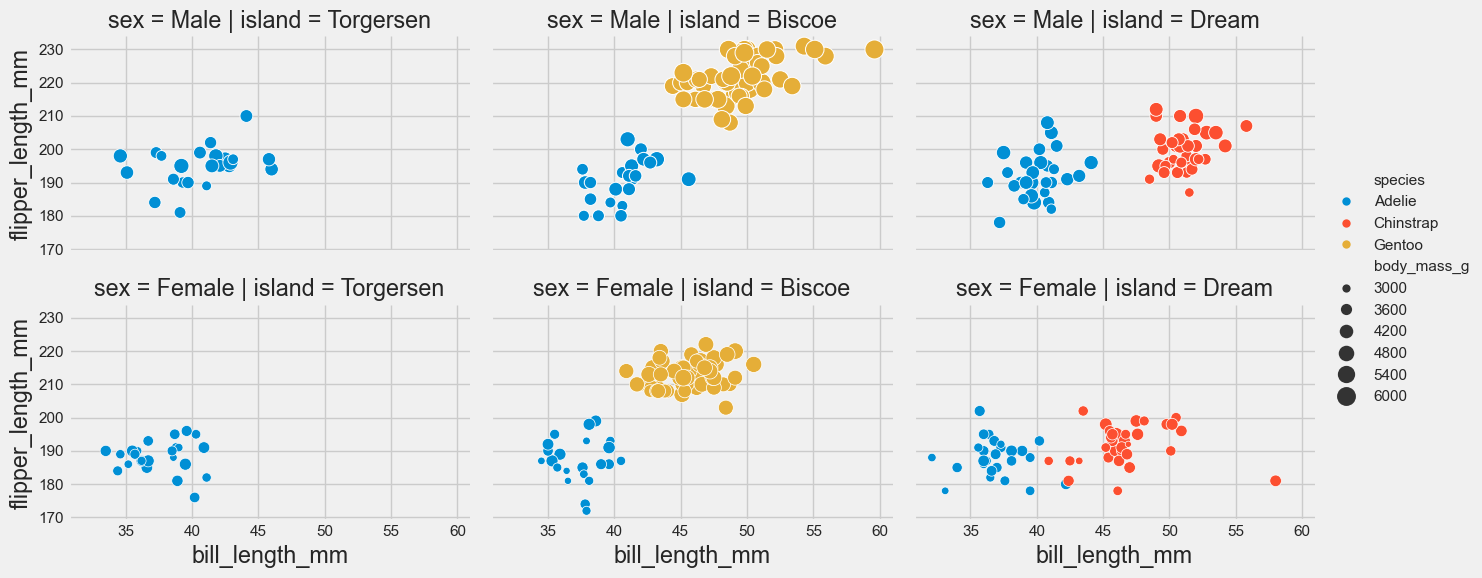

In [700]:
sns.relplot(x='bill_length_mm', 
            y='flipper_length_mm', 
            data=df, 
            hue='species', 
            col='island', 
            height=3, 
            aspect=1.5, 
            size='body_mass_g',
            row='sex',
            sizes=(20, 200));

In [701]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='bill_length_mm',
    y='bill_depth_mm',
    z='flipper_length_mm',
    color='species',
    size='body_mass_g'
)
fig.show()

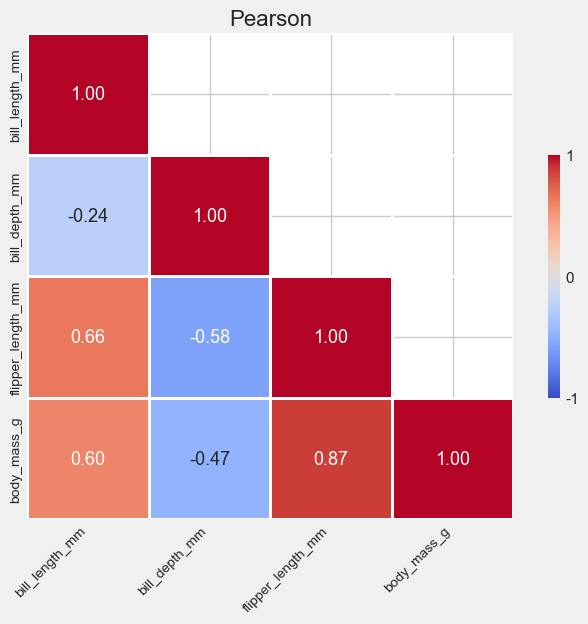

In [702]:
num_corr_heatmap(df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr())

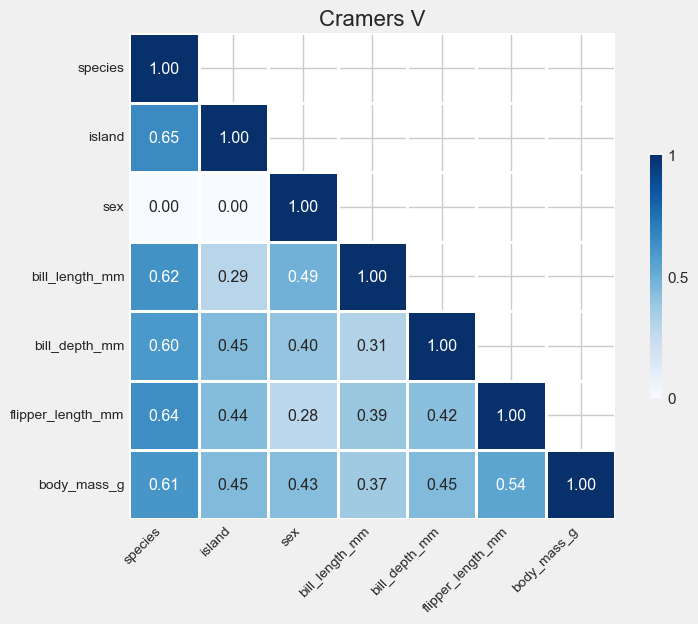

In [703]:
cramers_v = cramers_v_matrix(df)
cat_corr_heatmap(cramers_v);

In [704]:
df['bill_ratio'] = df['bill_length_mm'] / df['bill_depth_mm']
df['body_prop'] = df['flipper_length_mm'] / df['body_mass_g']

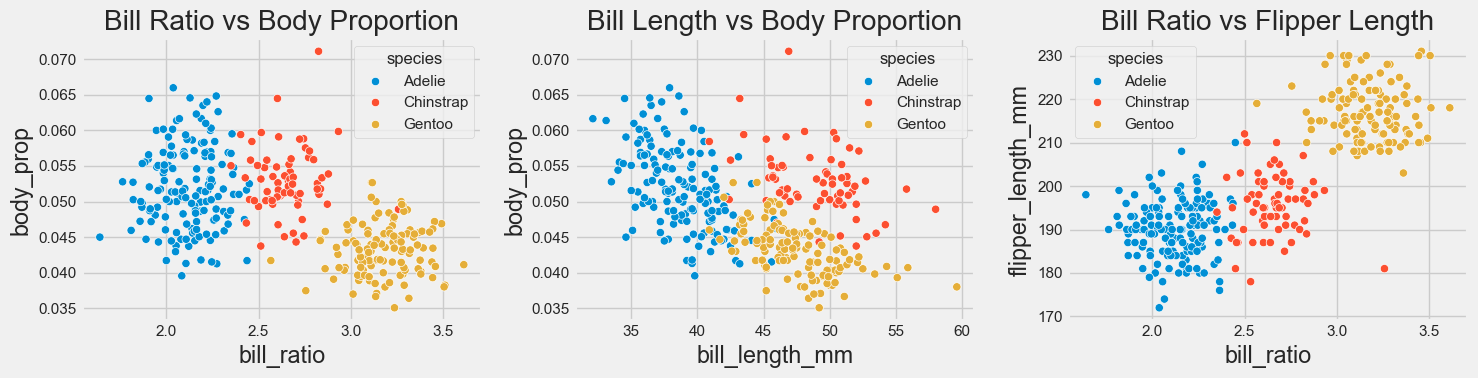

In [705]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(
    data=df,
    x='bill_ratio',
    y='body_prop',
    hue='species',
    ax=axes[0]
)
axes[0].set_title('Bill Ratio vs Body Proportion');
sns.scatterplot(
    data=df,
    x='bill_length_mm',
    y='body_prop',
    hue='species',
    ax=axes[1]
)
axes[1].set_title('Bill Length vs Body Proportion');
sns.scatterplot(
    data=df,
    x='bill_ratio',
    y='flipper_length_mm',
    hue='species',
    ax=axes[2]
)
axes[2].set_title('Bill Ratio vs Flipper Length');
plt.tight_layout();
plt.show()

In [706]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_ratio,body_prop
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,2.090909,0.048267
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,2.270115,0.048947
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,2.238889,0.060000
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,1.901554,0.055942
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1.907767,0.052055


In [707]:
X = df[['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'bill_ratio', 'body_prop']]
y = df['species']
X_train_80, X_test, y_train_80, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

In [708]:
numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
categorical_features = ['island', 'sex']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='if_binary', handle_unknown='error', sparse_output=False))
])

pseudo_transformer = FunctionTransformer(lambda x: x, feature_names_out='one-to-one')

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
        ('pseudo', pseudo_transformer, [])
    ],
    verbose_feature_names_out=False
).set_output(transform='pandas')

model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', KNeighborsClassifier(n_neighbors=3))
])

In [709]:
X_train, X_val, y_train, y_val = train_test_split(X_train_80, y_train_80, test_size=0.25, random_state=RANDOM_SEED, stratify=y_train_80)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)
    
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [710]:
def stratified_cv_scores(model, X, y, cv=5, random_state=RANDOM_SEED):
    cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    cv_precision = cross_val_score(model, X, y, cv=cv, scoring='precision_macro').mean()
    cv_recall = cross_val_score(model, X, y, cv=cv, scoring='recall_macro').mean()
    cv_f1 = cross_val_score(model, X, y, cv=cv, scoring='f1_macro').mean()
    cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring='accuracy').mean()
    return dict(precision=cv_precision, recall=cv_recall, f1=cv_f1, accuracy=cv_accuracy)

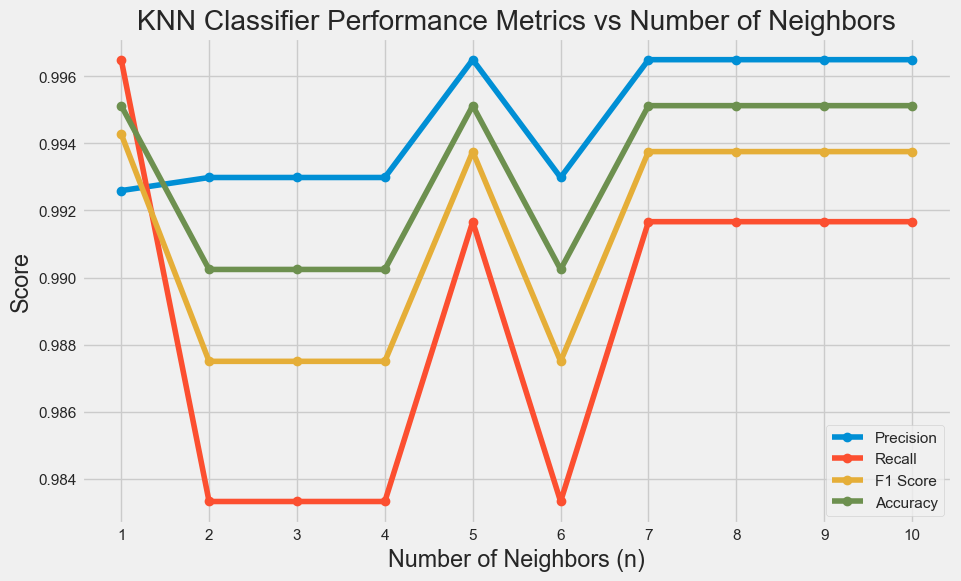

In [711]:
n_values = range(1, 11)
precision_scores = []
recall_scores = []
f1_scores = []
accuracy_scores = []

for n in n_values:
    model.set_params(clf__n_neighbors=n)
    cv_scores = stratified_cv_scores(model, X_train, y_train)
    precision_scores.append(cv_scores['precision'])
    recall_scores.append(cv_scores['recall'])
    f1_scores.append(cv_scores['f1'])
    accuracy_scores.append(cv_scores['accuracy'])

plt.figure(figsize=(10, 6))
plt.plot(n_values, precision_scores, label='Precision', marker='o')
plt.plot(n_values, recall_scores, label='Recall', marker='o')
plt.plot(n_values, f1_scores, label='F1 Score', marker='o')
plt.plot(n_values, accuracy_scores, label='Accuracy', marker='o')
plt.xlabel('Number of Neighbors (n)')
plt.ylabel('Score')
plt.title('KNN Classifier Performance Metrics vs Number of Neighbors')
plt.xticks(n_values)
plt.legend()
plt.show()

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



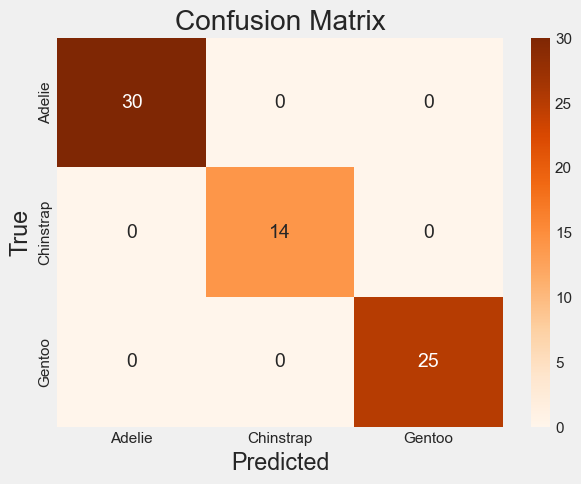

In [712]:
model.set_params(clf__n_neighbors=7)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)
print(classification_report(y_val, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_val, y_pred, labels=classes)
plot_confusion_matrix(cm, classes)
plt.show()

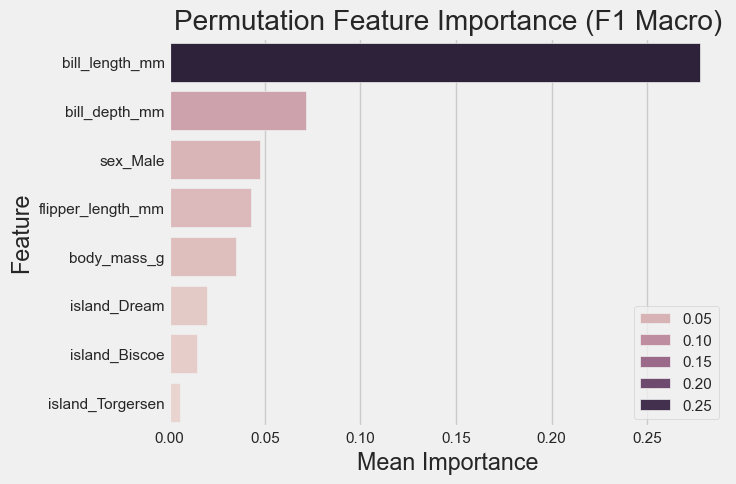

In [713]:
prep = model.named_steps['prep']
knn = model.named_steps['clf']
X_val_transformed = prep.transform(X_val)
result = permutation_importance(knn, X_val_transformed, y_val, n_repeats=30, random_state=RANDOM_SEED, n_jobs=-1, scoring='f1_macro')
feature_importances = pd.Series(result.importances_mean, index=prep.get_feature_names_out()).sort_values(ascending=False)
sns.barplot(x=feature_importances.values, y=feature_importances.index, hue=feature_importances.values)
plt.title('Permutation Feature Importance (F1 Macro)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

{'precision': 0.9895384615384616, 'recall': 0.9745454545454546, 'f1': 0.9808556311413454, 'accuracy': 0.9852525252525253}


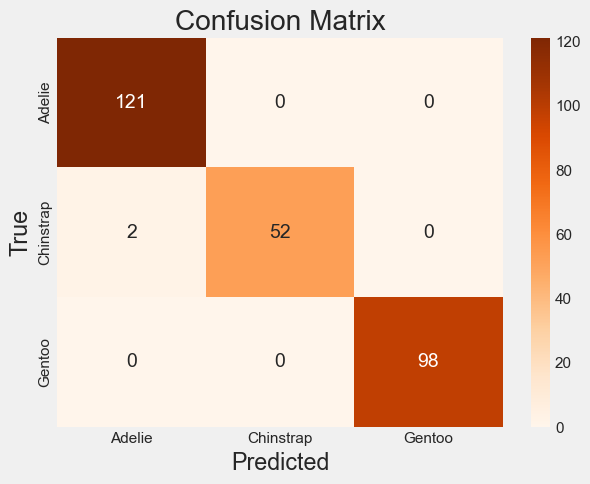

In [714]:
numerical_features = ['bill_length_mm', 'bill_depth_mm']
categorical_features = ['sex']

model.set_params(prep__transformers=
    [
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(cv_scores)
model.fit(X_train_80, y_train_80)
classes = model.named_steps['clf'].classes_
y_pred = model.predict(X_train_80)
cm = confusion_matrix(y_train_80, y_pred, labels=classes)
plot_confusion_matrix(cm, classes)
plt.show()

### Decision Tree Classifier

In [717]:
clf = DecisionTreeClassifier(
    random_state=RANDOM_SEED,
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None
)

categorical_features = ['island', 'sex']
numerical_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
model.set_params(
    clf=clf,
    prep__transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [718]:
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(f"Decision Tree Classifier CV Scores:")
print(f"F1 Macro: {cv_scores['f1']:.4f}")
print(f"Recall Macro: {cv_scores['recall']:.4f}")
print(f"Precision Macro: {cv_scores['precision']:.4f}")
print(f"Accuracy: {cv_scores['accuracy']:.4f}")

Decision Tree Classifier CV Scores:
F1 Macro: 0.9512
Recall Macro: 0.9524
Precision Macro: 0.9548
Accuracy: 0.9560


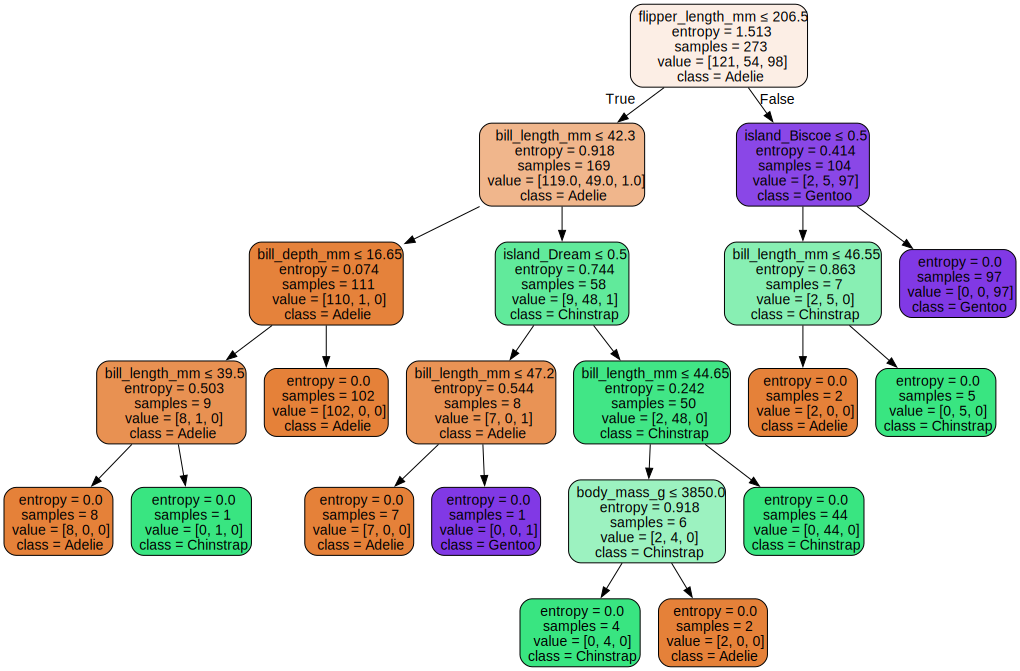

In [719]:
model.fit(X_train_80, y_train_80)
dt_graph(model)

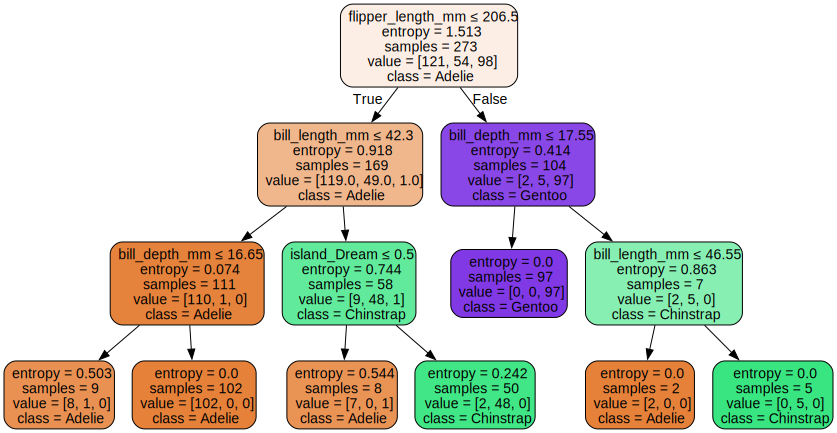

In [720]:
model.set_params(clf__max_depth=3)
model.fit(X_train_80, y_train_80)
dt_graph(model)

- flipper_length_mm > 206.5 & bill_depth_mm <= 17.55 -> Gentoo
- (flipper_length_mm > 206.5 & bill_depth_mm > 17.55 & bill_length_mm > 46.55) OR (flipper_length_mm <= 206.5 & bill_length_mm > 43.35 & island=="Dream") -> Chinstrap
- (flipper_length_mm > 206.5 & bill_depth_mm > 17.55 & bill_length_mm <= 46.55) OR (flipper_length_mm <= 206.5 & bill_length_mm <= 43.35) OR (flipper_length_mm <= 206.5 & bill_length_mm > 43.35 & island!="Dream") -> Adelie

In [674]:
cv_scores = stratified_cv_scores(model, X_train_80, y_train_80)
print(f"Decision Tree Classifier CV Scores:")
print(f"F1 Macro: {cv_scores['f1']:.4f}")
print(f"Recall Macro: {cv_scores['recall']:.4f}")
print(f"Precision Macro: {cv_scores['precision']:.4f}")
print(f"Accuracy: {cv_scores['accuracy']:.4f}")

Decision Tree Classifier CV Scores:
F1 Macro: 0.9511
Recall Macro: 0.9479
Precision Macro: 0.9602
Accuracy: 0.9560


              precision    recall  f1-score   support

      Adelie       0.96      0.99      0.98       121
   Chinstrap       0.98      0.93      0.95        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.98       273
   macro avg       0.98      0.97      0.97       273
weighted avg       0.98      0.98      0.98       273



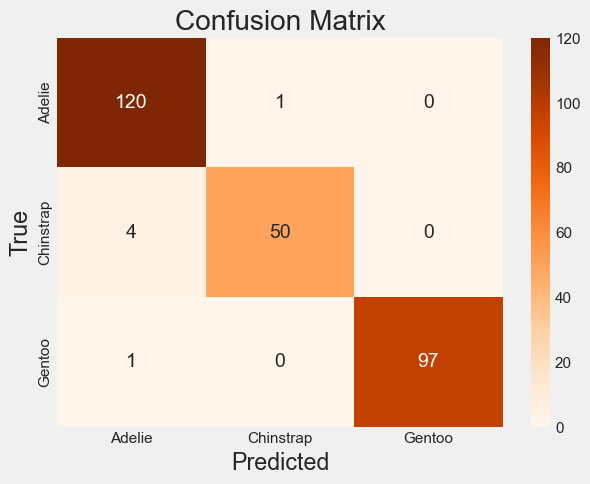

In [675]:
y_pred = model.predict(X_train_80)
print(classification_report(y_train_80, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_train_80, y_pred, labels=classes)

plot_confusion_matrix(cm, classes)
plt.show()

In [676]:
tree_rules = export_text(model.named_steps["clf"],
                         feature_names=model.named_steps["prep"].get_feature_names_out())
print(tree_rules)

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.30
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  42.30
|   |   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- island_Dream <= 0.50
|   |   |   |--- class: Adelie
|   |   |--- island_Dream >  0.50
|   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 17.55
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  17.55
|   |   |--- bill_length_mm <= 46.55
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  46.55
|   |   |   |--- class: Chinstrap



              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



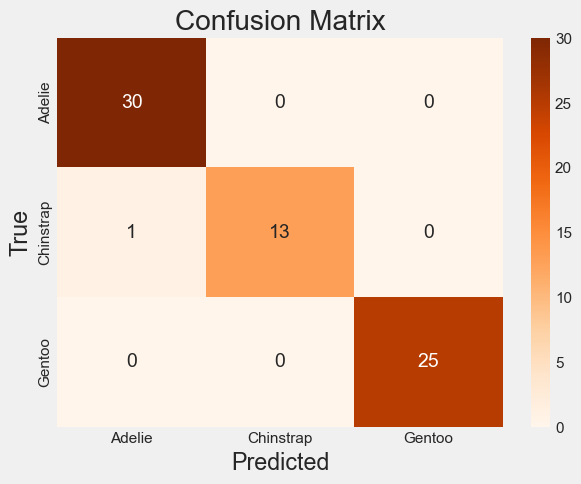

In [677]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
classes = model.named_steps['clf'].classes_
cm = confusion_matrix(y_test, y_pred, labels=classes)

plot_confusion_matrix(cm, classes)
plt.show()

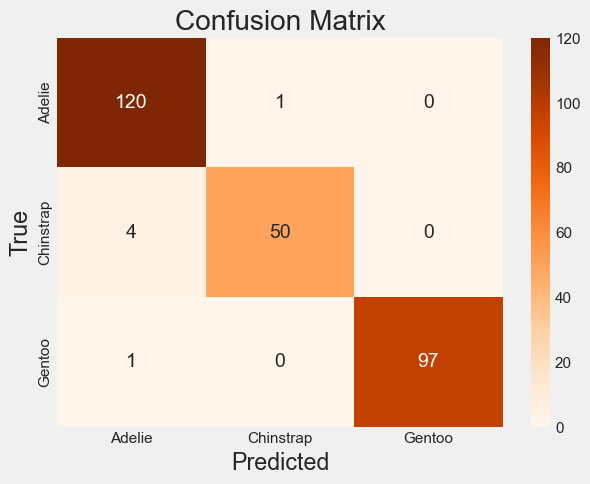

In [678]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35 and row.island == "Dream")
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"

y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       121
   Chinstrap       0.91      0.93      0.92        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.97       273
   macro avg       0.96      0.96      0.96       273
weighted avg       0.97      0.97      0.97       273



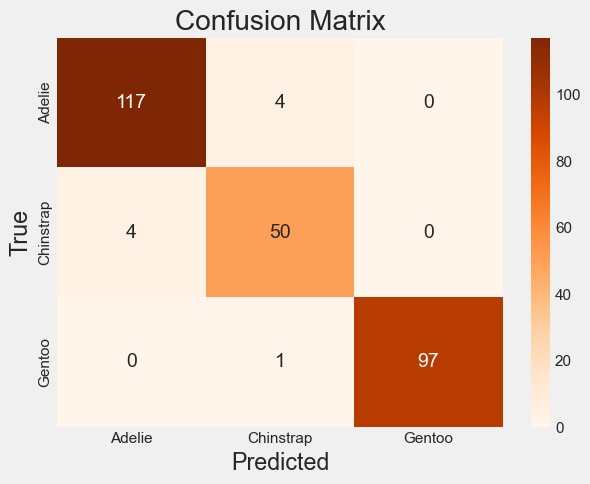

In [679]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35)
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
    
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

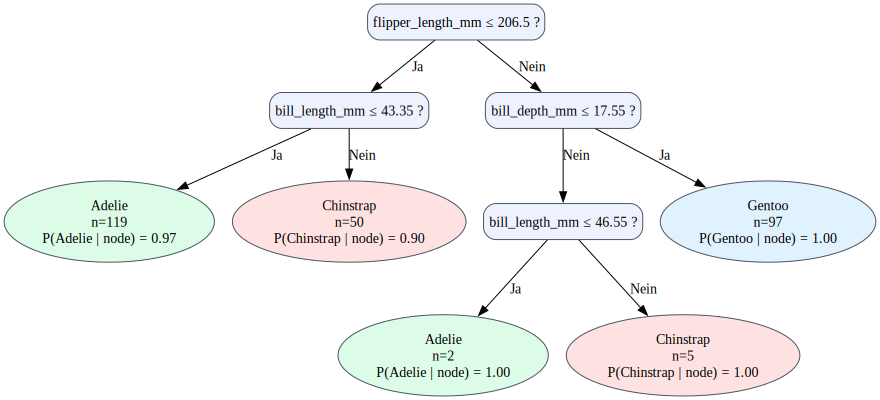

In [680]:
def rule_masks(df):
    left = df['flipper_length_mm'] <= 206.5
    right = ~left

    L_yes = left & (df['bill_length_mm'] <= 43.35)               # Adelie
    L_no  = left & (df['bill_length_mm'] > 43.35)                # Chinstrap

    R_yes = right & (df['bill_depth_mm'] <= 17.55)               # Gentoo
    R_no  = right & (df['bill_depth_mm'] > 17.55)
    R_no_yes = R_no & (df['bill_length_mm'] <= 46.55)            # Adelie
    R_no_no  = R_no & (df['bill_length_mm'] > 46.55)             # Chinstrap

    return {
        'L1_yes': L_yes, 'L1_no': L_no,
        'R1_yes': R_yes, 'R2_yes': R_no_yes, 'R2_no': R_no_no
    }

def label_with_stats(name, mask, y, cls_label, color):
    n = int(mask.sum())
    if n == 0:
        return f'{cls_label}\n(n=0)'
    dist = y[mask].value_counts(normalize=True).reindex(y.unique(), fill_value=0.0)
    p = dist.get(cls_label, 0.0)
    return f'{cls_label}\n n={n}\n P({cls_label} | node) = {p:.2f}'

masks = rule_masks(X_train_80)

dot = graphviz.Digraph('ManualRulesTreeStats', format='png')
dot.attr('node', shape='box', style='rounded,filled', color='#4b5563', fillcolor='#eef2ff')

dot.node('root', 'flipper_length_mm ≤ 206.5 ?')
dot.node('L1', 'bill_length_mm ≤ 43.35 ?'); dot.edge('root', 'L1', label='Ja')
dot.node('R1', 'bill_depth_mm ≤ 17.55 ?');   dot.edge('root', 'R1', label='Nein')
dot.node('R2', 'bill_length_mm ≤ 46.55 ?');  dot.edge('R1', 'R2', label='Nein')

# Leaves mit Stats
dot.node('L1_yes', label_with_stats('L1_yes', masks['L1_yes'], y_train_80, 'Adelie', '#dcfce7'),
         shape='oval', fillcolor='#dcfce7')
dot.node('L1_no',  label_with_stats('L1_no',  masks['L1_no'],  y_train_80, 'Chinstrap', '#fee2e2'),
         shape='oval', fillcolor='#fee2e2')
dot.edge('L1', 'L1_yes', label='Ja'); dot.edge('L1', 'L1_no', label='Nein')

dot.node('R1_yes', label_with_stats('R1_yes', masks['R1_yes'], y_train_80, 'Gentoo', '#e0f2fe'),
         shape='oval', fillcolor='#e0f2fe')
dot.edge('R1', 'R1_yes', label='Ja')

dot.node('R2_yes', label_with_stats('R2_yes', masks['R2_yes'], y_train_80, 'Adelie', '#dcfce7'),
         shape='oval', fillcolor='#dcfce7')
dot.node('R2_no',  label_with_stats('R2_no',  masks['R2_no'],  y_train_80, 'Chinstrap', '#fee2e2'),
         shape='oval', fillcolor='#fee2e2')
dot.edge('R2', 'R2_no', label='Nein')
dot.edge('R2', 'R2_yes', label='Ja')


dot.render('manual_rules_tree_stats', cleanup=True)
dot

              precision    recall  f1-score   support

      Adelie       0.97      0.95      0.96       121
   Chinstrap       0.90      0.83      0.87        54
      Gentoo       0.93      0.99      0.96        98

    accuracy                           0.94       273
   macro avg       0.93      0.92      0.93       273
weighted avg       0.94      0.94      0.94       273



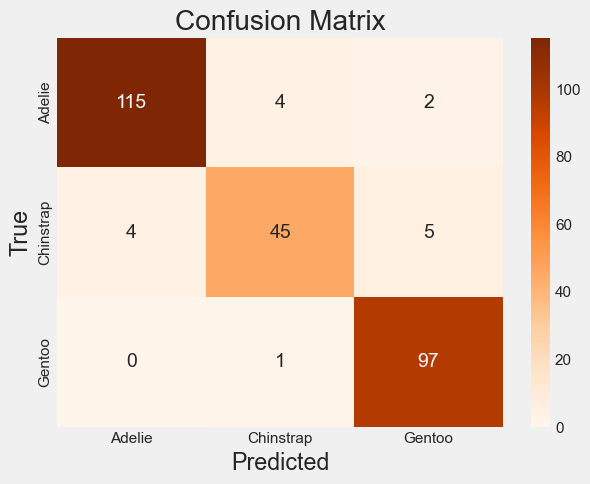

In [681]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5:
        return "Gentoo"
    else:
        if row.bill_length_mm > 43.35:
            return "Chinstrap"
        else:
            return "Adelie"
    

y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97       121
   Chinstrap       0.91      0.93      0.92        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.97       273
   macro avg       0.96      0.96      0.96       273
weighted avg       0.97      0.97      0.97       273



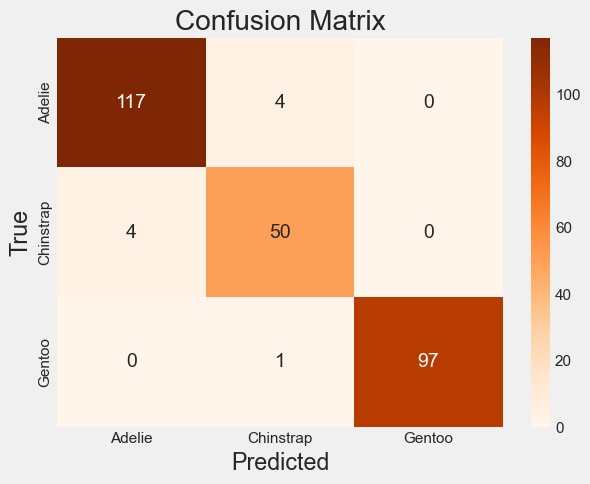

In [682]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35)
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.96      0.99      0.98       121
   Chinstrap       0.98      0.93      0.95        54
      Gentoo       1.00      0.99      0.99        98

    accuracy                           0.98       273
   macro avg       0.98      0.97      0.97       273
weighted avg       0.98      0.98      0.98       273



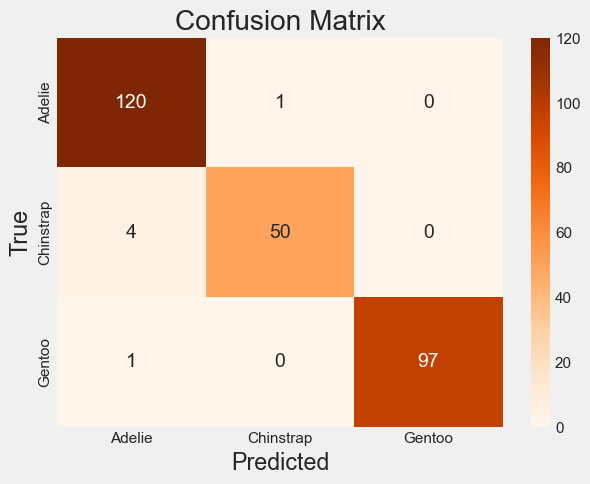

In [683]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5 and row.bill_depth_mm <= 17.55:
        return "Gentoo"
    elif ((row.flipper_length_mm <= 206.5 and row.bill_length_mm > 43.35 and row.island == "Dream")
          or (row.flipper_length_mm > 206.5 and row.bill_depth_mm > 17.55 and row.bill_length_mm > 46.55)):
        return "Chinstrap"
    else:
        return "Adelie"
y_pred = X_train_80.apply(dt_rule, axis=1) 
y_true = y_train_80

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

              precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           0.99        69
   macro avg       0.99      0.98      0.98        69
weighted avg       0.99      0.99      0.99        69



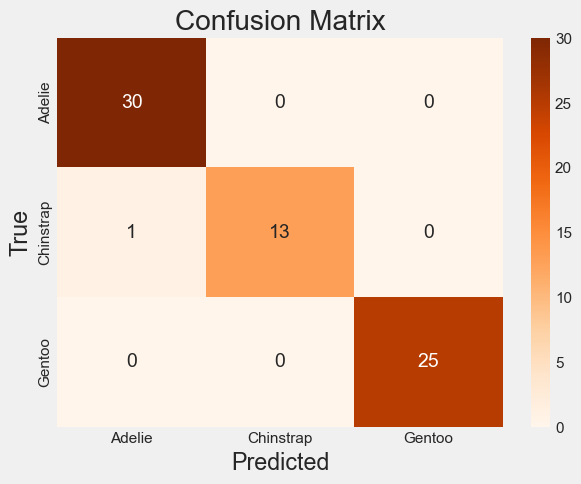

In [684]:
def dt_rule(row):
    if row.flipper_length_mm > 206.5:
        return "Gentoo"
    else:
        if row.bill_length_mm > 43.35:
            return "Chinstrap"
        else:
            return "Adelie"
    

y_pred = X_test.apply(dt_rule, axis=1) 
y_true = y_test

labels = ["Adelie", "Chinstrap", "Gentoo"]  
cm = confusion_matrix(y_true, y_pred, labels=labels)

print(classification_report(y_true, y_pred))

plot_confusion_matrix(cm, labels)
plt.show()

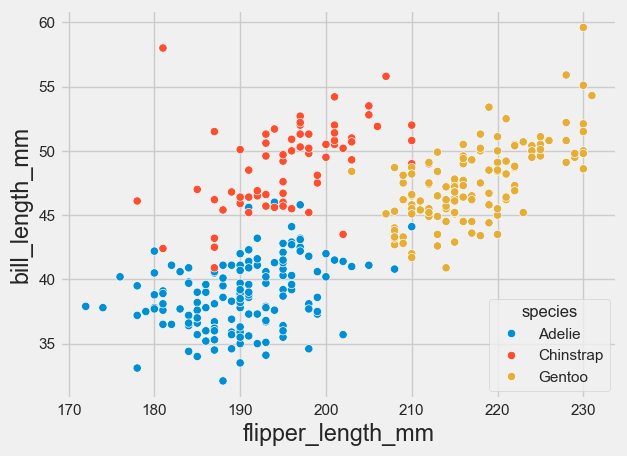

In [685]:
sns.scatterplot(data=df, x='flipper_length_mm', y='bill_length_mm', hue='species');

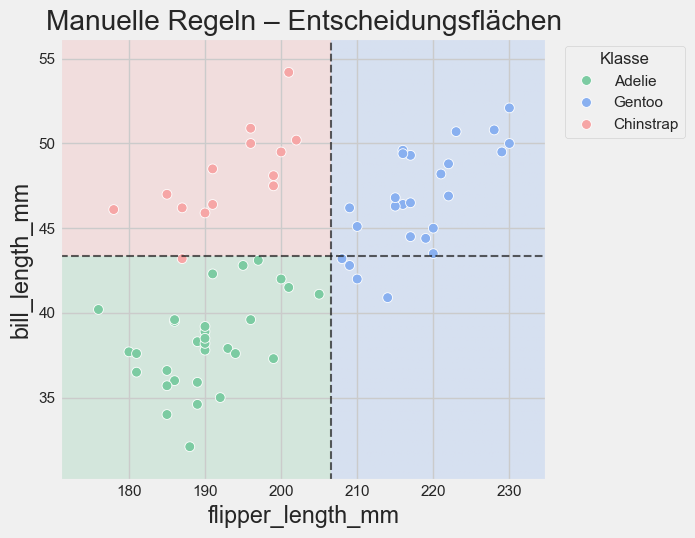

In [687]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Klassen & Farben (wie zuvor)
labels = ["Adelie", "Chinstrap", "Gentoo"]
palette = {"Adelie": "#7ccba2", "Chinstrap": "#f6a6a6", "Gentoo": "#89b0f0"}

# 1) Entscheidungsraster Z (mit Klassen-Strings) wie bisher berechnen …
#    Z hat shape wie xx/yy und Einträge "Adelie"/"Chinstrap"/"Gentoo"

# 2) Klassen-Strings → Indizes
label2idx = {c:i for i, c in enumerate(labels)}
Z_idx = np.vectorize(label2idx.get)(Z)  # jetzt int-Array

# 3) Colormap aus deiner Palette
cmap = ListedColormap([palette[c] for c in labels])

# 4) Plotten
plt.figure(figsize=(7.2, 5.6))
plt.imshow(
    Z_idx,
    origin="lower",
    extent=(x_min, x_max, y_min, y_max),
    cmap=cmap,
    alpha=0.25,
    aspect="auto",
    vmin=0, vmax=len(labels)-1
)

# Entscheidungsgrenzen
plt.axvline(thr_flipper, ls="--", lw=1.5, c="k", alpha=0.7)
plt.axhline(thr_bill,    ls="--", lw=1.5, c="k", alpha=0.7)

# Punkte (TRUE-Labels oder PRED-Labels – eins auswählen)
sns.scatterplot(
    data=X_test.assign(_y=y_true),  # oder y_pred
    x="flipper_length_mm", y="bill_length_mm",
    hue="_y", palette=palette, edgecolor="white", linewidth=0.6, s=50
)

plt.xlabel("flipper_length_mm"); plt.ylabel("bill_length_mm")
plt.title("Manuelle Regeln – Entscheidungsflächen")
plt.legend(title="Klasse", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()
